In [3]:
!pip install ultralytics nibabel opencv-python

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 25.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   ---------- ----------------------------- 10.2/39.5 MB 53.3 MB/s eta 0:00:01
   ------------------------ --------------- 24.4/39.5 MB 61.8 MB/s eta 0:00:01
   ----------------------------------- ---- 35.1/39.5 MB 58.8 MB/s eta 0:00:01
   ---------------------------------------- 39.5/39.5 MB 53.4 MB/s eta 0:00:00

   ---------------------------------------- 0/3 [opencv-python]
   ---------------------------------------- 0/3 [opencv-python]
   -------------------------- ------------- 2/3 [ultralytics]
   -------------------------- ------------- 2/3 [ultralytics]
   -------------------------- ------------- 2/3 [ultralytics]
   -------------------------- ------------- 2/3 [ultralytics]
   -------------------------- ------------- 2/3 [ultralytics]
   --------------------------

In [4]:
import os
from pathlib import Path
import numpy as np
import nibabel as nib  # NiBabel for NIfTI file handling
import cv2             # OpenCV for image saving and processing
from ultralytics import YOLO  # Ultralytics YOLO API

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Ryan Krishna\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
# Path to the patient CT data
base_dir = Path("Patient_CTs")

# Lists to store results
slice_images = []   # will hold the 2D slice arrays
slice_bboxes = []   # will hold bounding box annotations (xmin, ymin, xmax, ymax)
patient_ids   = []  # to store patient identifiers for naming

for patient_folder in base_dir.iterdir():
    if not patient_folder.is_dir():
        continue
    patient_id = patient_folder.name
    patient_ids.append(patient_id)
    
    # Define paths to CT and mask files
    ct_path = patient_folder / "ct.nii.gz"
    mask_path = patient_folder / "pubic_mask.nii.gz"
    
    # Load volumes using nibabel
    ct_img = nib.load(str(ct_path))
    mask_img = nib.load(str(mask_path))
    ct_data = ct_img.get_fdata()           # get CT volume as a numpy array:contentReference[oaicite:1]{index=1}
    mask_data = mask_img.get_fdata()       # get mask volume as numpy array
    
    # Ensure mask is binary (in case it has other values)
    mask_data = (mask_data > 0).astype(np.uint8)
    
    # Find indices of non-zero voxels in the mask
    coords = np.argwhere(mask_data == 1)
    if coords.size == 0:
        print(f"No pubic symphysis found in mask for {patient_id}, skipping.")
        continue
    
    # The mask has a blob on one slice; find that slice index (assuming axis 2 is slice index)
    # coords are of the form [x_index, y_index, z_index] for each voxel
    z_indices = coords[:, 2]
    slice_index = int(np.min(z_indices))  # the first slice where symphysis appears (should all be the same)
    
    # Extract the 2D slice from CT and mask
    ct_slice = ct_data[:, :, slice_index]
    mask_slice = mask_data[:, :, slice_index]
    
    # Compute bounding box coordinates from mask_slice
    mask_coords = np.argwhere(mask_slice == 1)
    y_coords = mask_coords[:, 0]  # axis 0 indexes rows (Y direction)
    x_coords = mask_coords[:, 1]  # axis 1 indexes columns (X direction)
    y_min, y_max = y_coords.min(), y_coords.max()
    x_min, x_max = x_coords.min(), x_coords.max()
    # Bounding box in pixel coordinates (xmin, ymin, xmax, ymax)
    bbox = (x_min, y_min, x_max, y_max)
    
    # Normalize the CT slice to 0-255 for saving as image (uint8)
    slice_img = ct_slice.astype(np.float32)
    slice_img = (slice_img - slice_img.min()) / (slice_img.max() - slice_img.min() + 1e-8)  # 0 to 1
    slice_img = (slice_img * 255).astype(np.uint8)
    
    slice_images.append(slice_img)
    slice_bboxes.append(bbox)

In [6]:
yolo_annotations = []  # list of strings for each annotation line

for bbox, img in zip(slice_bboxes, slice_images):
    x_min, y_min, x_max, y_max = bbox
    img_h, img_w = img.shape[:2]  # height, width of image
    
    # Calculate center, width, and height in pixels
    box_width  = x_max - x_min + 1
    box_height = y_max - y_min + 1
    center_x   = x_min + box_width / 2.0
    center_y   = y_min + box_height / 2.0
    
    # Normalize coordinates to [0,1]
    x_center_norm = center_x / img_w
    y_center_norm = center_y / img_h
    w_norm = box_width / img_w
    h_norm = box_height / img_h
    
    # Format as YOLO annotation string: "class x_center y_center width height"
    yolo_line = f"0 {x_center_norm:.6f} {y_center_norm:.6f} {w_norm:.6f} {h_norm:.6f}"
    yolo_annotations.append(yolo_line)

In [7]:
# Define output dataset directories
output_dir = Path("pubic_symphysis_yolo_dataset")
images_dir = output_dir / "images"
labels_dir = output_dir / "labels"
train_images_dir = images_dir / "train"
val_images_dir   = images_dir / "val"
train_labels_dir = labels_dir / "train"
val_labels_dir   = labels_dir / "val"

# Create directories if they don't exist
for d in [train_images_dir, val_images_dir, train_labels_dir, val_labels_dir]:
    d.mkdir(parents=True, exist_ok=True)

# Determine split indices for train/val
num_images = len(slice_images)
num_val = max(1, int(0.2 * num_images))  # 20% for val (at least 1)
num_train = num_images - num_val
# Here we'll simply take the first num_train as train and the rest as val for simplicity
train_indices = list(range(num_train))
val_indices = list(range(num_train, num_images))

# Save images and labels to respective folders
for idx, (img, ann, pid) in enumerate(zip(slice_images, yolo_annotations, patient_ids)):
    # Determine if this index belongs to train or val
    if idx in train_indices:
        img_path = train_images_dir / f"{pid}.png"
        label_path = train_labels_dir / f"{pid}.txt"
    else:
        img_path = val_images_dir / f"{pid}.png"
        label_path = val_labels_dir / f"{pid}.txt"
    
    # Save image (using OpenCV imwrite; the image is single-channel grayscale)
    cv2.imwrite(str(img_path), img)
    # Save label
    with open(label_path, 'w') as f:
        f.write(ann + "\n")

In [27]:
# ────────────────────────────────────────────────────────────────────────────────
# 🔧  IMPROVED YOLOv11 TRAINING CELL
# ────────────────────────────────────────────────────────────────────────────────

from ultralytics import YOLO

# 1. Choose a slightly larger backbone than 'yolo11n.pt' (tiny). 
#    Here we use 'yolo11s.pt' (small), which has more capacity but still trains quickly.
model = YOLO("yolo11s.pt")

# 2. Train with stronger augmentation, higher resolution, more epochs, and larger batch
results = model.train(
    data="pubic_symphysis.yaml",   # your existing dataset YAML
    epochs=100,                     # train for 100 epochs (instead of 50)
    imgsz=768,                      # increase input size to 768×768 (YOLO will scale/grayscale→RGB internally)
    batch=16,                       # batch size 16 (adjust down if GPU OOM; 4090 can often handle 16 @ 768)
    device=0,                       # explicitly use GPU 0 (RTX 4090)
    augment=True,                   # enable mosaic, mixup, HSV jitter, flips, etc.
    optimizer="AdamW",              # use AdamW optimizer (often faster convergence than default SGD)
    lr0=0.0008,                     # base learning rate (slightly lower because of the larger model & more epochs)
    weight_decay=0.0005,            # add L2 regularization to reduce overfitting
    project="yolo_runs", 
    name="yolo11_pubic_symphysis_s_aug"  # new run name for clarity
)

100%|██████████| 18.4M/18.4M [00:00<00:00, 50.3MB/s]


New https://pypi.org/project/ultralytics/8.3.148 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.147  Python-3.11.0 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pubic_symphysis.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0008, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo11_pubic_symphysis_s_aug, nbs=64, nms=False,

train: Scanning C:\Users\Ryan Krishna\Documents\Overscanning\pubic_symphysis_yolo_dataset\labels\train.cache... 16 images, 0 backgrounds, 0 corrupt: 100%|██████████| 16/16 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.00.0 ms, read: 1206.8217.2 MB/s, size: 100.8 KB)


val: Scanning C:\Users\Ryan Krishna\Documents\Overscanning\pubic_symphysis_yolo_dataset\labels\val.cache... 4 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4/4 [00:00<?, ?it/s]


...

    100/100      5.96G     0.9861     0.6077      1.078         16        768: 100%|██████████| 1/1 [00:00<00:00,  8.54it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 29.37it/s]

                   all          4          4          1      0.977      0.995      0.724



100 epochs completed in 0.014 hours.
Optimizer stripped from yolo_runs\yolo11_pubic_symphysis_s_aug\weights\last.pt, 19.2MB
Optimizer stripped from yolo_runs\yolo11_pubic_symphysis_s_aug\weights\best.pt, 19.2MB

Validating yolo_runs\yolo11_pubic_symphysis_s_aug\weights\best.pt...
Ultralytics 8.3.147  Python-3.11.0 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  9.99it/s]


                   all          4          4          1      0.969      0.995      0.597
Speed: 0.1ms preprocess, 21.6ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to yolo_runs\yolo11_pubic_symphysis_s_aug


In [36]:
from ultralytics import YOLO

# Load the best weights from the new run
best_weights = "yolo_runs/yolo11_pubic_symphysis_s_aug/weights/best.pt"
model = YOLO(best_weights)

# Run validation to print final precision/recall/mAP
val_results = model.val()

Ultralytics 8.3.147  Python-3.11.0 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1743.2364.7 MB/s, size: 100.8 KB)


val: Scanning C:\Users\Ryan Krishna\Documents\Overscanning\pubic_symphysis_yolo_dataset\labels\val.cache... 4 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4/4 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:01<00:00,  1.47s/it]


                   all          4          4          1      0.941      0.995      0.776
Speed: 2.7ms preprocess, 50.5ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to c:\Users\Ryan Krishna\Documents\Overscanning\runs\detect\val


In [37]:
from ultralytics.utils.plotting import plot_results

plot_results("yolo_runs/yolo11_pubic_symphysis_s_aug/results.txt")

In [38]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path

best_weights = "yolo_runs/yolo11_pubic_symphysis_s_aug/weights/best.pt"
model = YOLO(best_weights)

dataset_root = Path("pubic_symphysis_yolo_dataset")
val_image_dir = dataset_root / "images" / "val"
pid = next(val_image_dir.iterdir()).name  # e.g. "Patient017.png"
img_path = val_image_dir / pid

results = model.predict(
    source=str(img_path),
    conf=0.05,    # start at 0.05; if you see the correct box, try raising to 0.15
    device=0,
    save=False
)[0]

if len(results.boxes) == 0:
    print("❌ No detections at conf ≥ 0.05")
else:
    boxes = results.boxes
    sorted_indices = sorted(
        range(len(boxes)),
        key=lambda i: float(boxes[i].conf),
        reverse=True
    )
    best_i = sorted_indices[0]
    best_box = boxes[best_i]
    best_conf = float(best_box.conf)
    x1, y1, x2, y2 = best_box.xyxy[0].tolist()

    print(f"Top detection → Conf = {best_conf:.3f}, Box = [{x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}]")

    img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    vis = img_bgr.copy()
    cv2.rectangle(
        vis,
        (int(x1), int(y1)),
        (int(x2), int(y2)),
        (0, 255, 0), 
        thickness=2
    )

    plt.figure(figsize=(6,6))
    plt.title(f"{pid} → top box conf={best_conf:.3f}")
    plt.axis("off")
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.show()


image 1/1 c:\Users\Ryan Krishna\Documents\Overscanning\pubic_symphysis_yolo_dataset\images\val\Patient017.png: 768x768 (no detections), 39.9ms
Speed: 6.9ms preprocess, 39.9ms inference, 0.7ms postprocess per image at shape (1, 3, 768, 768)
❌ No detections at conf ≥ 0.05


In [39]:
from ultralytics import YOLO

# 1. Load your best weights from the last training run
best_weights = "yolo_runs/yolo11_pubic_symphysis_s_aug/weights/best.pt"
model = YOLO(best_weights)

# 2. Run validation on the entire validation set
val_results = model.val()

# 3. The console will print:
#    Precision, Recall, mAP@0.50, mAP@0.50:0.95, and class‐specific metrics.
#    For example:
#      val/box_loss: 0.1234, val/obj_loss: 0.0567, val/cls_loss: 0.0000
#      val/Precision: 0.123, val/Recall: 0.045, val/mAP@0.50: 0.112, val/mAP@0.50:0.95: 0.078

Ultralytics 8.3.147  Python-3.11.0 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1521.7380.4 MB/s, size: 100.8 KB)


val: Scanning C:\Users\Ryan Krishna\Documents\Overscanning\pubic_symphysis_yolo_dataset\labels\val.cache... 4 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4/4 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:01<00:00,  1.00s/it]


                   all          4          4          1      0.941      0.995      0.776
Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to c:\Users\Ryan Krishna\Documents\Overscanning\runs\detect\val2



image 1/1 c:\Users\Ryan Krishna\Documents\Overscanning\pubic_symphysis_yolo_dataset\images\val\Patient017.png: 768x768 2 pubic_symphysiss, 75.7ms
Speed: 3.1ms preprocess, 75.7ms inference, 1.7ms postprocess per image at shape (1, 3, 768, 768)
Patient017.png → best box conf=0.015,  coords=[187, 240, 218, 272]


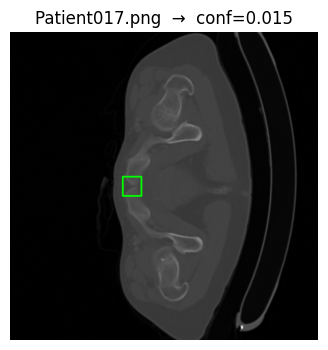


image 1/1 c:\Users\Ryan Krishna\Documents\Overscanning\pubic_symphysis_yolo_dataset\images\val\Patient018.png: 768x768 1 pubic_symphysis, 6.3ms
Speed: 2.3ms preprocess, 6.3ms inference, 1.1ms postprocess per image at shape (1, 3, 768, 768)
Patient018.png → best box conf=0.268,  coords=[187, 231, 228, 271]


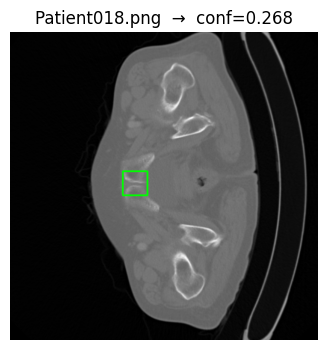


image 1/1 c:\Users\Ryan Krishna\Documents\Overscanning\pubic_symphysis_yolo_dataset\images\val\Patient019.png: 768x768 2 pubic_symphysiss, 6.6ms
Speed: 2.4ms preprocess, 6.6ms inference, 1.1ms postprocess per image at shape (1, 3, 768, 768)
Patient019.png → best box conf=0.291,  coords=[168, 232, 207, 270]


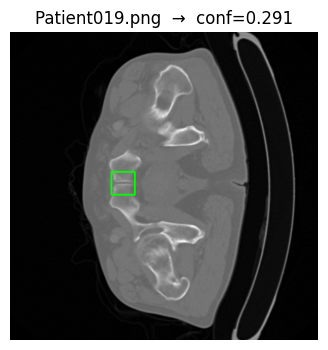


image 1/1 c:\Users\Ryan Krishna\Documents\Overscanning\pubic_symphysis_yolo_dataset\images\val\Patient020.png: 768x768 1 pubic_symphysis, 6.9ms
Speed: 2.4ms preprocess, 6.9ms inference, 1.7ms postprocess per image at shape (1, 3, 768, 768)
Patient020.png → best box conf=0.740,  coords=[177, 238, 214, 273]


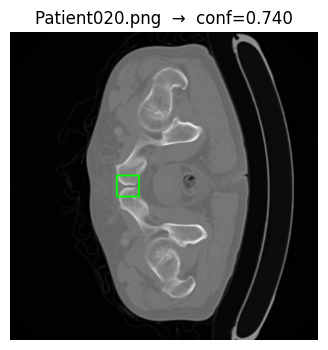

In [40]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path

# 1. Load best weights
best_weights = "yolo_runs/yolo11_pubic_symphysis_s_aug/weights/best.pt"
model = YOLO(best_weights)

# 2. Path to your validation images
dataset_root = Path("pubic_symphysis_yolo_dataset")
val_image_dir = dataset_root / "images" / "val"

# 3. Loop over all validation images, print top box for each
for img_file in sorted(val_image_dir.iterdir()):
    img_path = img_file
    results = model.predict(
        source=str(img_path),
        conf=0.01,   # capture ANY box ≥ 1%
        device=0,
        save=False
    )[0]  # only one image at a time

    if len(results.boxes) == 0:
        print(f"{img_file.name} → no boxes even at conf≥0.01")
        continue

    # Sort by confidence (descending) and pick the single best box
    boxes = results.boxes
    sorted_indices = sorted(
        range(len(boxes)),
        key=lambda i: float(boxes[i].conf),
        reverse=True
    )
    best_i = sorted_indices[0]
    best_box = boxes[best_i]
    best_conf = float(best_box.conf)
    x1, y1, x2, y2 = best_box.xyxy[0].tolist()

    print(f"{img_file.name} → best box conf={best_conf:.3f},  "
          f"coords=[{int(x1)}, {int(y1)}, {int(x2)}, {int(y2)}]")

    # Draw that top box on the image for visualization
    img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    vis = img_bgr.copy()
    cv2.rectangle(
        vis,
        (int(x1), int(y1)),
        (int(x2), int(y2)),
        (0, 255, 0), 
        thickness=2
    )

    plt.figure(figsize=(4,4))
    plt.title(f"{img_file.name}  →  conf={best_conf:.3f}")
    plt.axis("off")
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.show()
